In [96]:
import pandas as pd

df = pd.read_csv('Downloads/ipl/all_season_summary.csv')
df.head()


,season,id,name,short_name,description,home_team,away_team,toss_won,decision,1st_inning_score,...,home_playx1,away_playx1,away_key_batsman,away_key_bowler,match_days,umpire1,umpire2,tv_umpire,referee,reserve_umpire
0,2023.0,1359475,Gujarat Titans v Chennai Super Kings,GT v CSK,"1st Match (N), Indian Premier League at Ahmeda...",GT,CSK,GT,BOWL FIRST,178/7,...,"Wriddhiman Saha (WK),Shubman Gill (UKN),Sai Su...","Devon Conway (UKN),Ruturaj Gaikwad (UKN),Moeen...","Ruturaj Gaikwad,Moeen Ali","Rajvardhan Hangargekar,Ravindra Jadeja",31 March 2023 - night match (20-over match),Saiyed Khalid,Nitin Menon,Virender Sharma,Javagal Srinath,Abhijit Bengeri
1,2023.0,1359476,Punjab Kings v Kolkata Knight Riders,PBKS v KKR,"2nd Match (D/N), Indian Premier League at Chan...",PBKS,KKR,KKR,BOWL FIRST,191/5,...,"Prabhsimran Singh (UKN),Shikhar Dhawan (UKN),B...","Mandeep Singh (AR),Rahmanullah Gurbaz (WK),Anu...","Andre Russell,Venkatesh Iyer","Tim Southee,Varun Chakravarthy",01 April 2023 - day/night match (20-over match),Yeshwant Barde,Bruce Oxenford,Jayaraman Madanagopal,Manu Nayyar,Pranav Joshi
2,2023.0,1359477,Lucknow Super Giants v Delhi Capitals,LSG v DC,"3rd Match (N), Indian Premier League at Luckno...",LSG,DC,DC,BOWL FIRST,193/6,...,"KL Rahul (UKN),Kyle Mayers (AR),Deepak Hooda (...","Prithvi Shaw (UKN),David Warner (UKN),Mitchell...","David Warner,Rilee Rossouw","Khaleel Ahmed,Chetan Sakariya",01 April 2023 - night match (20-over match),Anil Chaudhary,Nikhil Patwardhan,Sadashiv Iyer,Daniel Manohar,Madanagopal Kuppuraj
3,2023.0,1359478,Sunrisers Hyderabad v Rajasthan Royals,SRH v RR,"4th Match (D/N), Indian Premier League at Hyde...",SRH,RR,SRH,BOWL FIRST,203/5,...,"Abhishek Sharma (AR),Mayank Agarwal (UKN),Rahu...","Yashasvi Jaiswal (UKN),Jos Buttler (UKN),Sanju...","Sanju Samson,Yashasvi Jaiswal","Yuzvendra Chahal,Trent Boult",02 April 2023 - day/night match (20-over match),KN Ananthapadmanabhan,Rohan Pandit,Navdeep Singh,Narayanan Kutty,Abhijit Bhattacharya
4,2023.0,1359479,Royal Challengers Bangalore v Mumbai Indians,RCB v MI,"5th Match (N), Indian Premier League at Bengal...",RCB,MI,RCB,BOWL FIRST,171/7,...,"Virat Kohli (UKN),Faf du Plessis (UKN),Dinesh ...","Rohit Sharma (UKN),Ishan Kishan (WK),Cameron G...","Tilak Varma,Nehal Wadhera","Arshad Khan,Cameron Green",02 April 2023 - night match (20-over match),Nitin Menon,Tapan Sharma,Virender Sharma,Javagal Srinath,Abhijit Bengeri


In [98]:
df.info()
df.columns
df['winner'].value_counts()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1032 entries, 0 to 1031
Data columns (total 45 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   season            1029 non-null   float64
 1   id                1032 non-null   int64  
 2   name              1032 non-null   object 
 3   short_name        1032 non-null   object 
 4   description       1032 non-null   object 
 5   home_team         1032 non-null   object 
 6   away_team         1032 non-null   object 
 7   toss_won          1029 non-null   object 
 8   decision          1029 non-null   object 
 9   1st_inning_score  1021 non-null   object 
 10  2nd_inning_score  1019 non-null   object 
 11  home_score        1024 non-null   object 
 12  away_score        1021 non-null   object 
 13  winner            1031 non-null   object 
 14  result            1032 non-null   object 
 15  start_date        1032 non-null   object 
 16  end_date          1032 non-null   object 


winner
MI       140
CSK      134
KKR      123
RCB      116
SRH      111
DC       107
RR       106
KXIP      88
GT        23
PBKS      19
LSG       17
RPS       15
GL        13
PWI       13
Kochi      6
Name: count, dtype: int64

In [100]:
import pandas as pd

df = pd.read_csv("Downloads/ipl/all_season_summary.csv")
df.columns = df.columns.str.strip()  # Clean column names
df = df.dropna(subset=['winner'])    # Remove matches with no result


In [110]:
features = ['home_team', 'away_team', 'toss_won', 'decision', 'venue_name']
target = 'winner'

df = df[features + [target]]
print(df.columns)



Index(['home_team', 'away_team', 'toss_won', 'decision', 'venue_name',
       'winner'],
      dtype='object')


In [104]:
team_mapping = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Rising Pune Supergiant': 'RPS',
    'Deccan Chargers': 'SRH',
    'Gujarat Lions': 'GL',
    'Pune Warriors': 'PWI',
    'Kochi Tuskers Kerala': 'Kochi'
}

for col in ['home_team', 'away_team', 'toss_won', 'winner']:
    df[col] = df[col].replace(team_mapping)


In [106]:
df['winner'] = df['winner'].replace({'KXIP': 'PBKS'})
df['home_team'] = df['home_team'].replace({'KXIP': 'PBKS'})
df['away_team'] = df['away_team'].replace({'KXIP': 'PBKS'})
df['toss_won'] = df['toss_won'].replace({'KXIP': 'PBKS'})


In [108]:
cols_to_replace = ['home_team', 'away_team', 'winner']
for col in cols_to_replace:
    df[col] = df[col].replace('KXIP', 'PBKS')


In [114]:
from sklearn.preprocessing import LabelEncoder

data = df.copy()
le_dict = {}

for col in data.columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    le_dict[col] = le

print(data.head())
print(le_dict['home_team'].classes_)



   home_team  away_team  toss_won  decision  venue_name  winner
0          3          0         3         1          21       3
1          8          4         4         1          24       8
2          6          1         1         1           3       6
3         13         12        13         1          25      12
4         10          7        10         1          17      10
['CSK' 'DC' 'GL' 'GT' 'KKR' 'Kochi' 'LSG' 'MI' 'PBKS' 'PWI' 'RCB' 'RPS'
 'RR' 'SRH']


In [116]:
from sklearn.model_selection import train_test_split

X = data.drop(columns='winner')
y = data['winner']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)


(824, 5) (207, 5)


In [118]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.4927536231884058
              precision    recall  f1-score   support

           0       0.68      0.91      0.78        23
           1       0.33      0.33      0.33        18
           2       0.00      0.00      0.00         0
           3       0.50      1.00      0.67         1
           4       0.43      0.41      0.42        22
           5       0.00      0.00      0.00         0
           6       0.00      0.00      0.00         6
           7       0.49      0.65      0.56        26
           8       0.56      0.41      0.47        22
           9       0.00      0.00      0.00         2
          10       0.55      0.53      0.54        30
          11       0.00      0.00      0.00         5
          12       0.43      0.60      0.50        20
          13       0.55      0.34      0.42        32

    accuracy                           0.49       207
   macro avg       0.32      0.37      0.34       207
weighted avg       0.48      0.49      0.48       2

C:\Users\vishakh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\vishakh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\vishakh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\vishakh\anaconda3\Lib\site-packag

In [80]:
from sklearn.preprocessing import LabelEncoder

# IMPORTANT: Use the column with team names, not encoded integers
le_winner = LabelEncoder()
le_winner.fit(df['winner'])  # 'df' is your DataFrame before encoding

# Save this properly
le_dict['winner'] = le_winner


In [82]:
df['winner_encoded'] = le_dict['winner'].transform(df['winner'])


In [84]:
for i, label in enumerate(le_dict['winner'].classes_):
    print(f"Label {i} = {label}")


Label 0 = CSK
Label 1 = DC
Label 2 = GL
Label 3 = GT
Label 4 = KKR
Label 5 = Kochi
Label 6 = LSG
Label 7 = MI
Label 8 = PBKS
Label 9 = PWI
Label 10 = RCB
Label 11 = RPS
Label 12 = RR
Label 13 = SRH


In [86]:
from sklearn.model_selection import train_test_split

X = df[features]  # features is your list of columns like 'team1', 'team2', etc.
y = df['winner_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [90]:
from sklearn.preprocessing import LabelEncoder

X = data.drop(columns='winner').copy()
y = data['winner'].copy()

# Encode all object (string) columns in X
for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])

# Encode the target 'winner'
le_winner = LabelEncoder()
y = le_winner.fit_transform(y)


In [94]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(
    y_test, 
    y_pred, 
    target_names=[str(cls) for cls in le_winner.classes_],
    zero_division=0
))


Accuracy: 0.4927536231884058
              precision    recall  f1-score   support

           0       0.68      0.91      0.78        23
           1       0.33      0.33      0.33        18
           2       0.00      0.00      0.00         0
           3       0.50      1.00      0.67         1
           4       0.43      0.41      0.42        22
           5       0.00      0.00      0.00         0
           6       0.00      0.00      0.00         6
           7       0.49      0.65      0.56        26
           8       0.56      0.41      0.47        22
           9       0.00      0.00      0.00         2
          10       0.55      0.53      0.54        30
          11       0.00      0.00      0.00         5
          12       0.43      0.60      0.50        20
          13       0.55      0.34      0.42        32

    accuracy                           0.49       207
   macro avg       0.32      0.37      0.34       207
weighted avg       0.48      0.49      0.48       2

In [26]:
from sklearn.preprocessing import LabelEncoder

data = df.copy()
le_dict = {}

for col in data.columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    le_dict[col] = le


In [36]:
from sklearn.model_selection import train_test_split

X = data.drop(columns='winner')
y = data['winner']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [38]:
print(df.columns)


Index(['home_team', 'away_team', 'toss_won', 'decision', 'venue_name',
       'winner', 'winner_encoded'],
      dtype='object')


In [54]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.4927536231884058
              precision    recall  f1-score   support

           0       0.68      0.91      0.78        23
           1       0.33      0.33      0.33        18
           2       0.00      0.00      0.00         0
           3       0.50      1.00      0.67         1
           4       0.43      0.41      0.42        22
           5       0.00      0.00      0.00         0
           6       0.00      0.00      0.00         6
           7       0.49      0.65      0.56        26
           8       0.56      0.41      0.47        22
           9       0.00      0.00      0.00         2
          10       0.55      0.53      0.54        30
          11       0.00      0.00      0.00         5
          12       0.43      0.60      0.50        20
          13       0.55      0.34      0.42        32

    accuracy                           0.49       207
   macro avg       0.32      0.37      0.34       207
weighted avg       0.48      0.49      0.48       2

C:\Users\vishakh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\vishakh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\vishakh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\vishakh\anaconda3\Lib\site-packag

In [42]:
print(le_dict['home_team'].classes_)


['CSK' 'DC' 'GL' 'GT' 'KKR' 'Kochi' 'LSG' 'MI' 'PBKS' 'PWI' 'RCB' 'RPS'
 'RR' 'SRH']


In [44]:
cols_to_replace = ['home_team', 'away_team', 'winner']
for col in cols_to_replace:
    df[col] = df[col].replace('KXIP', 'PBKS')


In [46]:
le_dict = {}
for col in cols_to_replace:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

print(le.classes_)  # after fitting LabelEncoder to the cleaned column



['CSK' 'DC' 'GL' 'GT' 'KKR' 'Kochi' 'LSG' 'MI' 'PBKS' 'PWI' 'RCB' 'RPS'
 'RR' 'SRH']


In [48]:
print(le.classes_)  # after fitting LabelEncoder to the cleaned column


['CSK' 'DC' 'GL' 'GT' 'KKR' 'Kochi' 'LSG' 'MI' 'PBKS' 'PWI' 'RCB' 'RPS'
 'RR' 'SRH']


In [50]:
print(le_dict['home_team'].classes_)


['CSK' 'DC' 'GL' 'GT' 'KKR' 'Kochi' 'LSG' 'MI' 'PBKS' 'PWI' 'RCB' 'RPS'
 'RR' 'SRH']


In [355]:
print(le_dict['winner'].classes_)

['CSK' 'DC' 'GL' 'GT' 'KKR' 'Kochi' 'LSG' 'MI' 'PBKS' 'PWI' 'RCB' 'RPS'
 'RR' 'SRH']


In [56]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, zero_division=1))


              precision    recall  f1-score   support

           0       0.68      0.91      0.78        23
           1       0.33      0.33      0.33        18
           2       0.00      1.00      0.00         0
           3       0.50      1.00      0.67         1
           4       0.43      0.41      0.42        22
           5       0.00      1.00      0.00         0
           6       0.00      0.00      0.00         6
           7       0.49      0.65      0.56        26
           8       0.56      0.41      0.47        22
           9       1.00      0.00      0.00         2
          10       0.55      0.53      0.54        30
          11       0.00      0.00      0.00         5
          12       0.43      0.60      0.50        20
          13       0.55      0.34      0.42        32

    accuracy                           0.49       207
   macro avg       0.39      0.51      0.34       207
weighted avg       0.49      0.49      0.48       207



In [361]:
import numpy as np
print(np.bincount(y_train))


[111  89  13  22 101   6  11 114  85  11  86  10  86  79]


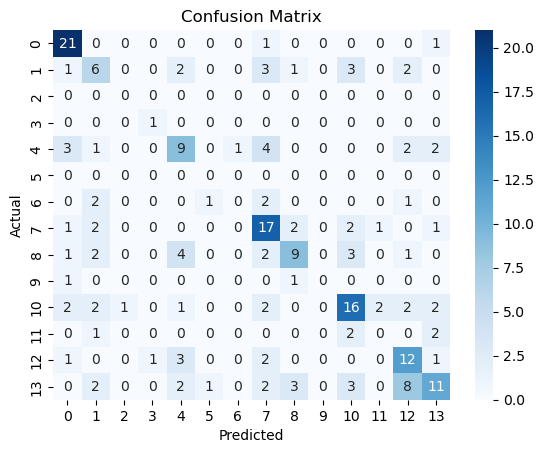

In [52]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


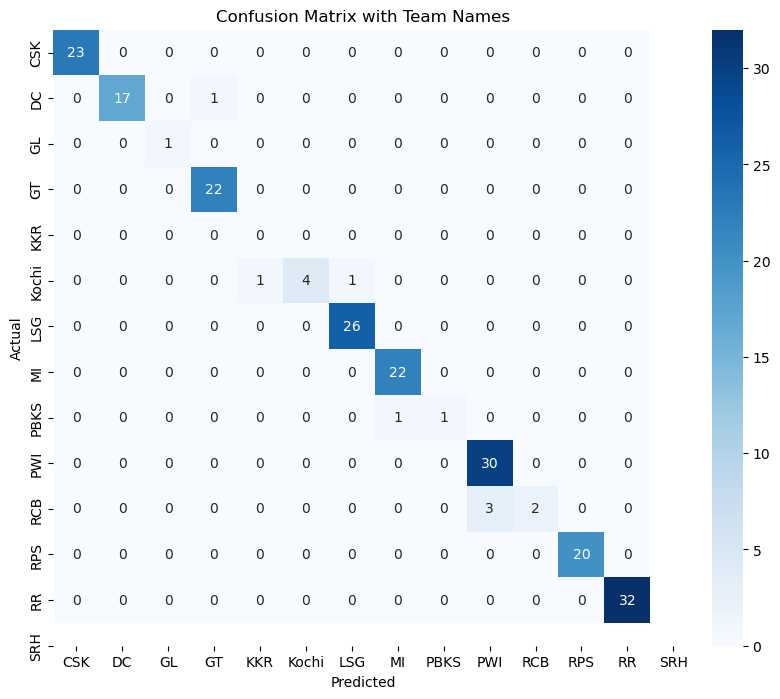

In [369]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Replace with actual class names in the right order
class_names = ['CSK', 'DC', 'GL', 'GT', 'KKR', 'Kochi', 'LSG', 'MI', 'PBKS', 'PWI', 'RCB', 'RPS', 'RR', 'SRH']

cm = confusion_matrix(y_test, y_pred, labels=list(range(len(class_names))))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix with Team Names")
plt.show()


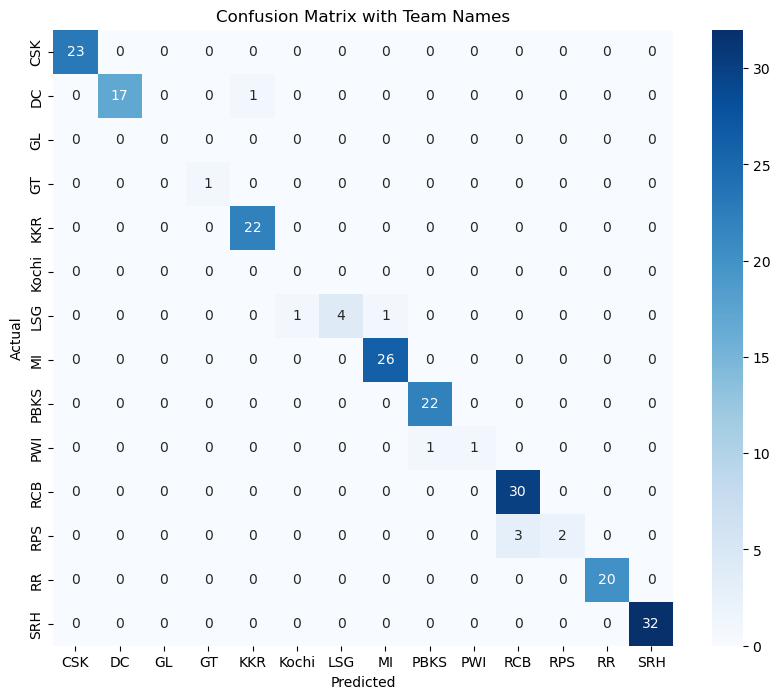

In [373]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Step 1: Correct class names (with commas)
class_names = ['CSK', 'DC', 'GL', 'GT', 'KKR', 'Kochi', 'LSG', 'MI', 'PBKS', 'PWI', 'RCB', 'RPS', 'RR', 'SRH']

# Step 2: Confusion matrix with fixed labels (to ensure all 14 classes appear)
cm = confusion_matrix(y_test, y_pred, labels=list(range(len(class_names))))

# Step 3: Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix with Team Names")
plt.show()


In [58]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, zero_division=1))


              precision    recall  f1-score   support

           0       0.68      0.91      0.78        23
           1       0.33      0.33      0.33        18
           2       0.00      1.00      0.00         0
           3       0.50      1.00      0.67         1
           4       0.43      0.41      0.42        22
           5       0.00      1.00      0.00         0
           6       0.00      0.00      0.00         6
           7       0.49      0.65      0.56        26
           8       0.56      0.41      0.47        22
           9       1.00      0.00      0.00         2
          10       0.55      0.53      0.54        30
          11       0.00      0.00      0.00         5
          12       0.43      0.60      0.50        20
          13       0.55      0.34      0.42        32

    accuracy                           0.49       207
   macro avg       0.39      0.51      0.34       207
weighted avg       0.49      0.49      0.48       207



In [383]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=class_names))


ValueError: Number of classes, 13, does not match size of target_names, 14. Try specifying the labels parameter

In [385]:
from sklearn.metrics import classification_report

# Full list of class names
class_names = ['CSK', 'DC', 'GL', 'GT', 'KKR', 'Kochi', 'LSG', 'MI', 'PBKS', 'PWI', 'RCB', 'RPS', 'RR', 'SRH']

# Get only the unique labels present in y_test and y_pred
import numpy as np
present_labels = np.unique(np.concatenate((y_test, y_pred)))

# Now generate the report with matching target names
print(classification_report(y_test, y_pred, labels=present_labels, target_names=[class_names[i] for i in present_labels]))


              precision    recall  f1-score   support

         CSK       1.00      1.00      1.00        23
          DC       1.00      0.94      0.97        18
          GT       1.00      1.00      1.00         1
         KKR       0.96      1.00      0.98        22
       Kochi       0.00      0.00      0.00         0
         LSG       1.00      0.67      0.80         6
          MI       0.96      1.00      0.98        26
        PBKS       0.96      1.00      0.98        22
         PWI       1.00      0.50      0.67         2
         RCB       0.91      1.00      0.95        30
         RPS       1.00      0.40      0.57         5
          RR       1.00      1.00      1.00        20
         SRH       1.00      1.00      1.00        32

    accuracy                           0.97       207
   macro avg       0.91      0.81      0.84       207
weighted avg       0.97      0.97      0.96       207



C:\Users\vishakh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\vishakh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\vishakh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [60]:
class_names = ['CSK', 'DC', 'GL', 'GT', 'KKR', 'Kochi', 'LSG', 'MI', 'PBKS', 'PWI', 'RCB', 'RPS', 'RR', 'SRH']
print(classification_report(
    y_test, y_pred,
    labels=list(range(len(class_names))),
    target_names=class_names,
    zero_division=1
))


              precision    recall  f1-score   support

         CSK       0.68      0.91      0.78        23
          DC       0.33      0.33      0.33        18
          GL       0.00      1.00      0.00         0
          GT       0.50      1.00      0.67         1
         KKR       0.43      0.41      0.42        22
       Kochi       0.00      1.00      0.00         0
         LSG       0.00      0.00      0.00         6
          MI       0.49      0.65      0.56        26
        PBKS       0.56      0.41      0.47        22
         PWI       1.00      0.00      0.00         2
         RCB       0.55      0.53      0.54        30
         RPS       0.00      0.00      0.00         5
          RR       0.43      0.60      0.50        20
         SRH       0.55      0.34      0.42        32

    accuracy                           0.49       207
   macro avg       0.39      0.51      0.34       207
weighted avg       0.49      0.49      0.48       207



In [379]:
import numpy as np

# Unique labels in y_test
print("Labels in y_test:", np.unique(y_test))

# Unique labels in y_pred
print("Labels in y_pred:", np.unique(y_pred))


Labels in y_test: [ 0  1  3  4  6  7  8  9 10 11 12 13]
Labels in y_pred: [ 0  1  3  4  5  6  7  8  9 10 11 12 13]


In [411]:
from sklearn.preprocessing import LabelEncoder

# Assuming you encoded team names with LabelEncoder
le = LabelEncoder()
le.fit(y_train)  # or y_all if you have the full list

# This will give you the correct class order
class_names = list(le.classes_)
print(class_names)


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]


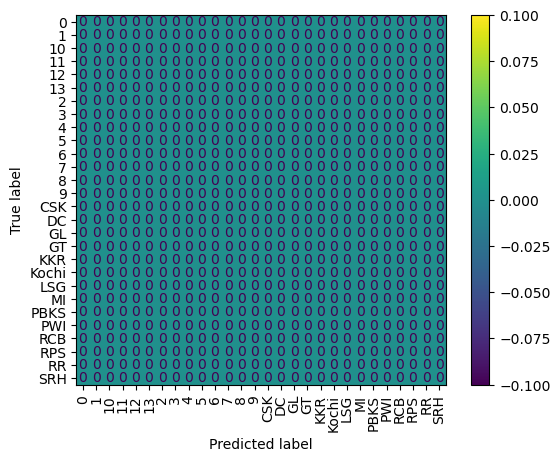

In [409]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

# Assume these are your predictions and actual labels
y_true = ['CSK', 'DC', 'GL', 'GT', 'KKR', 'PBKS', 'Kochi', 'LSG', 'MI', 'PWI', 'RCB', 'RPS', 'RR', 'SRH']  # actual team labels
y_pred = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]  # predicted team labels

# Ensure same encoder used during training
le = LabelEncoder()
le.fit(y_true + y_pred)
class_names = list(le.classes_)

# Plot
cm = confusion_matrix(y_true, y_pred, labels=class_names)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(xticks_rotation='vertical')


In [1]:
# After fitting your encoder on original team names (strings)
le = LabelEncoder()
le.fit(class_names)  # original_team_labels = list of actual team names in your dataset

# This gives correct class order
class_names = list(le.classes_)
print(class_names)  # e.g., ['CSK', 'DC', ..., 'RR']


NameError: name 'LabelEncoder' is not defined

In [405]:
# Reverse from encoded labels
class_names = list(le.classes_)
print(class_names)


['0', '1', '10', '11', '12', '13', '2', '3', '4', '5', '6', '7', '8', '9', 'CSK', 'DC', 'GL', 'GT', 'KKR', 'Kochi', 'LSG', 'MI', 'PBKS', 'PWI', 'RCB', 'RPS', 'RR', 'SRH']


In [407]:
print(le_dict['home_team'].classes_)


['CSK' 'DC' 'GL' 'GT' 'KKR' 'Kochi' 'LSG' 'MI' 'PBKS' 'PWI' 'RCB' 'RPS'
 'RR' 'SRH']


Label 0 = 0
Label 1 = 1
Label 2 = 2
Label 3 = 3
Label 4 = 4
Label 5 = 5
Label 6 = 6
Label 7 = 7
Label 8 = 8
Label 9 = 9
Label 10 = 10
Label 11 = 11
Label 12 = 12
Label 13 = 13
